# BD Academy — Training Recommendation Pipeline

**Project:** Talent-matching internship capstone  
**Goal:** Match healthcare professionals (HCPs) to the BD Academy training modules that best fit their profile, objectives, and constraints.

---

## Pipeline Overview

| Stage | Name | Purpose |
|-------|------|---------|
| 0 | Data Loading & Cleaning | Load datasets, enforce integrity, cast types |
| 1 | Feature Engineering | Build text fields and profile sentences |
| 2 | Dual Embedding | TF-IDF + LSA and Sentence-BERT |
| 3 | Cosine Similarity | Compute customer ↔ module similarity matrices |
| 4 | Score Fusion + Category Boosting | Blend embeddings, apply domain-aware rules |
| 5 | MMR Re-ranking | Ensure diverse, non-redundant recommendations |
| 6 | Output | Export top-K recommendations per customer |

---

### Why no clustering?

> Clustering is an unsupervised technique designed to *discover* hidden groupings when no labels exist. Our modules already have `Topic_Domain` and `Business_Unit_Full` — expert-defined categories built by BD's own domain specialists. Running K-Means on top of that would only rediscover, in a noisier form, structure we already have in a column. Instead, we use those categories directly as explicit boosters in Stage 4, which is more interpretable, more controllable, and more honest about what the data provides.

### Why two embeddings?

> **TF-IDF + LSA** excels at exact keyword and product-name matching — critical for BD's branded product names (BD Alaris™, Pyxis ES, BD Vacutainer®). **Sentence-BERT** captures semantic intent even when exact words differ (e.g. *"reduce medication errors"* matching *"infusion safety protocols"*), and generalises well across the 20+ languages in the dataset when a multilingual model is used. The two are complementary and fused with a weighted blend.

---
## Dependencies

In [1]:
# Core scientific stack — should already be present in any standard environment
import warnings
import os
import json

import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, normalize

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# sentence-transformers: install once with:
#   pip install sentence-transformers
# If unavailable, set USE_SBERT = False below to run in TF-IDF only mode.
try:
    from sentence_transformers import SentenceTransformer
    SBERT_AVAILABLE = True
except ImportError:
    SBERT_AVAILABLE = False
    print("⚠️  sentence-transformers not installed. Running in TF-IDF only mode.")
    print("   Install with: pip install sentence-transformers")

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Blues_d")
pd.set_option("display.max_colwidth", 80)

print("✅ Imports complete")

⚠️  sentence-transformers not installed. Running in TF-IDF only mode.
   Install with: pip install sentence-transformers
✅ Imports complete


---
## Configuration

All tunable parameters live here so you never have to hunt through the code.

In [2]:
# ── File paths ────────────────────────────────────────────────────────────────
MODULES_PATH   = "BD_Dataset1_Training_Modules_v3.csv"
CUSTOMERS_PATH = "BD_Dataset2_HCP_Profiles_v3.csv"
OUTPUT_DIR     = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Embedding settings ────────────────────────────────────────────────────────
USE_SBERT   = SBERT_AVAILABLE   # flip to False to force TF-IDF only mode

# Recommended SBERT models (trade-off: speed ↔ quality ↔ multilingual support)
#   all-MiniLM-L6-v2                         → fast, strong English
#   all-mpnet-base-v2                         → slower, best English quality
#   paraphrase-multilingual-MiniLM-L12-v2    → multilingual, good speed  ✅ recommended for BD
#   paraphrase-multilingual-mpnet-base-v2    → multilingual, highest quality
SBERT_MODEL = "paraphrase-multilingual-MiniLM-L12-v2"

LSA_COMPONENTS = 150     # TF-IDF dimensionality after SVD reduction
TFIDF_NGRAM    = (1, 2)  # unigrams + bigrams

# ── Fusion weights ────────────────────────────────────────────────────────────
# SBERT weighted higher because it generalises better across languages.
# Raise TF-IDF weight if exact product-name matching is more critical.
W_TFIDF = 0.35
W_SBERT = 0.65

# ── Rule-based boost magnitudes ───────────────────────────────────────────────
BOOST_LANGUAGE       = 0.06   # customer language == module language
BOOST_DOMAIN         = 0.08   # customer objective maps to module Topic_Domain
BOOST_OPCO           = 0.05   # both customer and module are OPCO-eligible
BOOST_CONTRACT_CERT  = 0.03   # contract customer + certified module
BOOST_SKILL          = 0.04   # module is at or just above customer skill level
BOOST_FORMAT         = 0.03   # customer's preferred format matches module format
PENALTY_DURATION     = 0.10   # module duration exceeds customer availability

# ── MMR settings ──────────────────────────────────────────────────────────────
TOP_K       = 5     # number of recommendations per customer
MMR_LAMBDA  = 0.70  # 1.0 = pure relevance, 0.0 = pure diversity
CANDIDATE_POOL = 50 # pre-filter to top-N before MMR re-ranking

print("✅ Configuration set")
print(f"   SBERT enabled : {USE_SBERT}")
print(f"   SBERT model   : {SBERT_MODEL}")
print(f"   Top-K         : {TOP_K}")
print(f"   Fusion weights: TF-IDF={W_TFIDF}  SBERT={W_SBERT}")

✅ Configuration set
   SBERT enabled : False
   SBERT model   : paraphrase-multilingual-MiniLM-L12-v2
   Top-K         : 5
   Fusion weights: TF-IDF=0.35  SBERT=0.65


---
## Stage 0 — Data Loading & Cleaning

We enforce three things here before any modelling begins:
1. **Primary key integrity** — `Module_ID`, `Module_Title`, `Description`, and `Customer_ID` must have zero nulls and be unique.
2. **Active-only modules** — Inactive modules (`Course_Active != YES`) are filtered out so they never surface as recommendations.
3. **Column dropping** — `Target_Roles` is dropped. BD's website does not expose this field, so it carries no signal we can rely on.

In [3]:
# ── Load modules ──────────────────────────────────────────────────────────────
modules_raw = pd.read_csv(MODULES_PATH, encoding="utf-8-sig")
print(f"Modules loaded  : {modules_raw.shape[0]:,} rows × {modules_raw.shape[1]} cols")

# Drop columns not present / not useful
DROP_MODULE_COLS = ["Target_Roles", "Created_By"]
modules_raw.drop(columns=[c for c in DROP_MODULE_COLS if c in modules_raw.columns], inplace=True)

# Primary key checks
assert modules_raw["Module_ID"].notna().all(),    "❌ Module_ID has nulls"
assert modules_raw["Module_Title"].notna().all(), "❌ Module_Title has nulls"
assert modules_raw["Description"].notna().all(),  "❌ Description has nulls"
assert modules_raw["Module_ID"].is_unique,        "❌ Duplicate Module_IDs"

# Type casting
modules_raw["Duration_Hours"] = pd.to_numeric(modules_raw["Duration_Hours"], errors="coerce").fillna(1.0)
modules_raw["Course_Active"]  = modules_raw["Course_Active"].str.strip().str.upper().fillna("YES")

CAT_MODULE_COLS = ["Skill_Level", "Training_Type", "Delivery_Format",
                   "Topic_Domain", "Business_Unit", "Business_Unit_Full",
                   "OPCO_Eligible", "Certification", "Language", "Country"]
for col in CAT_MODULE_COLS:
    if col in modules_raw.columns:
        modules_raw[col] = modules_raw[col].fillna("Unknown").str.strip()

# Keep only active modules
modules_df = modules_raw[modules_raw["Course_Active"] == "YES"].copy().reset_index(drop=True)
print(f"Active modules  : {modules_df.shape[0]:,} rows")

print("\n✅ Module primary keys valid")
modules_df.head(3)

Modules loaded  : 1,000 rows × 19 cols
Active modules  : 1,000 rows

✅ Module primary keys valid


,Module_ID,Module_Title,Business_Unit_Full,Business_Unit,Topic_Domain,Training_Type,Delivery_Format,Duration_Hours,Skill_Level,Language,Country,Certification,OPCO_Eligible,Prerequisites_Module_ID,Course_Active,Created_Date,Description
0,BD8808,BD Instaflash™ Needle Technology,Medication Delivery Solutions,MDS,Vascular Access & Infusion,Product Training,Webinar,2.0,Advanced,English (United Kingdom),United Kingdom,No,No,BD0159,YES,8/9/24,BDLA module on PICCline insertion with ECG-guided tip confirmation. Covers p...
1,BD8018,BD Pyxis CIISafe Formulary Workbook without ES Integration,Medication Management Solutions,MMS,Medication Management,BDLA,Blended,2.0,Intermediate,English (United Kingdom),United States,No,Yes,NaN,YES,4/11/22,"System Manager-level training on Pyxis Enterprise Server reporting, user adm..."
2,BD6019,Budget like a Boss 2.0,Select Business,SB,Medication Management,BDLA,Masterclass,1.0,Intermediate,English (United Kingdom),Select Country,No,Yes,NaN,YES,5/5/23,"General orientation training for BD product users. Covers company values, qu..."


In [4]:
# ── Load customers ────────────────────────────────────────────────────────────
customers_df = pd.read_csv(CUSTOMERS_PATH, encoding="utf-8-sig")
print(f"Customers loaded: {customers_df.shape[0]:,} rows × {customers_df.shape[1]} cols")

# Primary key checks
assert customers_df["Customer_ID"].notna().all(), "❌ Customer_ID has nulls"
assert customers_df["Customer_ID"].is_unique,     "❌ Duplicate Customer_IDs"

# Type casting
customers_df["Years_Experience"]         = pd.to_numeric(customers_df["Years_Experience"], errors="coerce").fillna(5)
customers_df["Available_Time_Hours"]     = pd.to_numeric(customers_df["Available_Time_Hours"], errors="coerce").fillna(8)
customers_df["Satisfaction_Score_Proxy"] = pd.to_numeric(customers_df["Satisfaction_Score_Proxy"], errors="coerce")

CAT_CUST_COLS = ["Customer_Role", "Specialty_Service", "Skill_Level_Self_Assessed",
                 "OPCO_Eligibility", "Has_BD_Contract", "Format_Preference",
                 "Training_Objective", "Preferred_BD_Product", "Country", "Language"]
for col in CAT_CUST_COLS:
    if col in customers_df.columns:
        customers_df[col] = customers_df[col].fillna("Unknown").str.strip()

print("\n✅ Customer primary keys valid")
customers_df.head(3)

Customers loaded: 1,000 rows × 17 cols

✅ Customer primary keys valid


,Customer_ID,Customer_Role,Specialty_Service,Establishment_Type,Country,Language,Years_Experience,Skill_Level_Self_Assessed,OPCO_Eligibility,Has_BD_Contract,Format_Preference,Available_Time_Hours,Training_Objective,Preferred_BD_Product,Prior_BD_Trainings,Completed_Training_Treatment,Satisfaction_Score_Proxy
0,HCP0001,Biomedical Engineer,Microbiology,Universitätsklinikum,Germany,Deutsch (de) - German,20,Intermediate,No,Yes,Blended,4,Develop vascular access unit expertise,Unknown,BD5366,No,3.8
1,HCP0002,Nurse,Trauma ICU,IPSS,Portugal,Português (pt) - Portuguese,30,Beginner,No,Yes,Masterclass,24,Validate Qualiopi competencies for task delegation,BD PICCline,NaN,Yes,4.7
2,HCP0003,Physician,Réanimation,Private Hospital,United Kingdom,English (United Kingdom),18,Intermediate,No,No,E-learning,4,Improve pre-analytical quality and reduce specimen non-conformances,BD PICCline,NaN,Yes,4.4


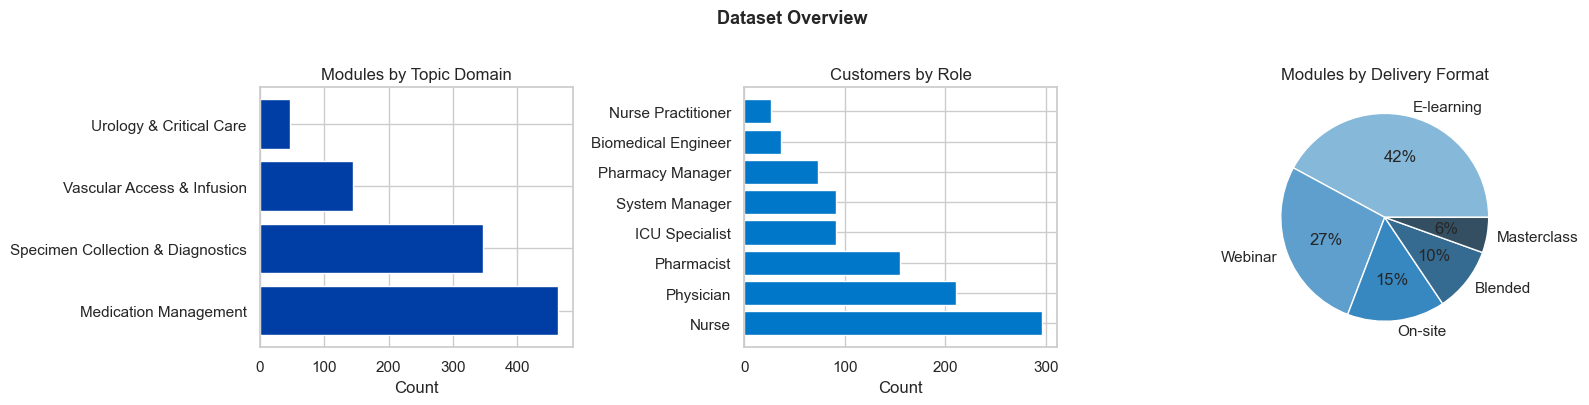

In [5]:
# ── Quick dataset overview ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Topic domain distribution
td_counts = modules_df["Topic_Domain"].value_counts()
axes[0].barh(td_counts.index, td_counts.values, color="#003DA5")
axes[0].set_title("Modules by Topic Domain")
axes[0].set_xlabel("Count")

# Customer role distribution
role_counts = customers_df["Customer_Role"].value_counts().head(8)
axes[1].barh(role_counts.index, role_counts.values, color="#0077C8")
axes[1].set_title("Customers by Role")
axes[1].set_xlabel("Count")

# Delivery format
fmt_counts = modules_df["Delivery_Format"].value_counts()
axes[2].pie(fmt_counts.values, labels=fmt_counts.index, autopct="%1.0f%%",
            colors=sns.color_palette("Blues_d", len(fmt_counts)))
axes[2].set_title("Modules by Delivery Format")

plt.suptitle("Dataset Overview", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/dataset_overview.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Stage 1 — Feature Engineering

### 1a — Module Text Field

We concatenate several columns into one rich text string per module. `Topic_Domain` is repeated twice — this is intentional: it slightly upweights domain keywords in TF-IDF without hard-coding any rules, which helps the model distinguish between e.g. a TTM module and a Pyxis module even when the description alone is ambiguous.

### 1b — Customer Profile Sentence

This is the most important engineering decision in the pipeline. Instead of encoding customers as a sparse feature vector (which lives in a different space than module text), we **convert each customer profile into a natural-language sentence**.

This puts customers and modules **in the same semantic embedding space**, which is what makes cosine similarity meaningful. The sentence captures role, specialty, skill level, objective, location, language, format preference, availability, and product interest.

In [6]:
# ── 1a: Module text ───────────────────────────────────────────────────────────
def build_module_text(df: pd.DataFrame) -> pd.Series:
    """
    Concatenate Description + Topic_Domain (×2) + Training_Type + Skill_Level
    + Module_Title into one rich text string per module.
    Topic_Domain is repeated to boost its TF-IDF weight without hard-coding rules.
    """
    return (
        df["Description"].fillna("")    + " " +
        df["Topic_Domain"].fillna("")   + " " +
        df["Topic_Domain"].fillna("")   + " " +   # intentional repeat
        df["Training_Type"].fillna("")  + " " +
        df["Skill_Level"].fillna("")    + " " +
        df["Module_Title"].fillna("")
    ).str.strip()

module_texts = build_module_text(modules_df)

print("Sample module text:")
print("-" * 80)
print(module_texts.iloc[0])

Sample module text:
--------------------------------------------------------------------------------
BDLA module on PICCline insertion with ECG-guided tip confirmation. Covers pre-insertion patient assessment, sterile technique, and post-insertion verification. Vascular Access & Infusion Vascular Access & Infusion Product Training Advanced BD Instaflash™ Needle Technology


In [7]:
# ── 1b: Customer profile sentence ────────────────────────────────────────────

# Ordinal mapping used in the sentence template and later in score fusion
SKILL_ORDER = {"Beginner": 0, "Intermediate": 1, "Advanced": 2, "Expert": 3}
SKILL_PHRASES = {
    "Beginner":     "with limited experience",
    "Intermediate": "with moderate clinical experience",
    "Advanced":     "with extensive clinical experience",
    "Expert":       "with expert-level clinical expertise",
}

def build_customer_sentence(row: pd.Series) -> str:
    """
    Convert a customer profile row into a single descriptive sentence.

    Why a sentence and not a feature vector?
    ─────────────────────────────────────────
    Module descriptions are text. If we embed customers as sparse numeric
    vectors, they live in a completely different space from modules — cosine
    similarity between them would be meaningless.

    By converting the customer profile to natural language, we project both
    customers and modules into the same embedding space, making similarity
    a valid and meaningful measure.

    Example output:
      "Nurse specialised in Critical Care with extensive clinical experience,
       objective: improve infusion safety. Based at CHU in France, language:
       Français. Prefers E-learning, available for 8 hours.
       OPCO-eligible for certified training. Product interest: BD Alaris™."
    """
    skill   = SKILL_PHRASES.get(str(row.get("Skill_Level_Self_Assessed", "")),
                                 "with clinical experience")
    opco    = " OPCO-eligible for certified training." \
              if str(row.get("OPCO_Eligibility", "")).lower() == "yes" else ""
    product = f" Product interest: {row['Preferred_BD_Product']}." \
              if str(row.get("Preferred_BD_Product", "Unknown")).lower() \
                 not in ("unknown", "nan", "") else ""

    return (
        f"{row.get('Customer_Role', 'Professional')} specialised in "
        f"{row.get('Specialty_Service', 'clinical care')} {skill}, "
        f"objective: {row.get('Training_Objective', 'professional development')}. "
        f"Based at {row.get('Establishment_Type', 'hospital')} in "
        f"{row.get('Country', 'Europe')}, language: {row.get('Language', 'English')}. "
        f"Prefers {row.get('Format_Preference', 'E-learning')}, "
        f"available for {row.get('Available_Time_Hours', 8)} hours."
        f"{opco}{product}"
    )

customer_sentences = customers_df.apply(build_customer_sentence, axis=1)

print("Sample customer sentences:")
print("-" * 80)
for i in range(3):
    print(f"[HCP{i+1:04d}] {customer_sentences.iloc[i]}")
    print()

Sample customer sentences:
--------------------------------------------------------------------------------
[HCP0001] Biomedical Engineer specialised in Microbiology with moderate clinical experience, objective: Develop vascular access unit expertise. Based at Universitätsklinikum in Germany, language: Deutsch (de) - German. Prefers Blended, available for 4 hours.

[HCP0002] Nurse specialised in Trauma ICU with limited experience, objective: Validate Qualiopi competencies for task delegation. Based at IPSS in Portugal, language: Português (pt) - Portuguese. Prefers Masterclass, available for 24 hours. Product interest: BD PICCline.

[HCP0003] Physician specialised in Réanimation with moderate clinical experience, objective: Improve pre-analytical quality and reduce specimen non-conformances. Based at Private Hospital in United Kingdom, language: English (United Kingdom). Prefers E-learning, available for 4 hours. Product interest: BD PICCline.



---
## Stage 2 — Dual Embedding

### TF-IDF + LSA (Latent Semantic Analysis)

TF-IDF vectorises text based on term frequency weighted by inverse document frequency — terms that appear everywhere carry less signal. We apply **TruncatedSVD** (LSA) on top to reduce dimensionality from the full vocabulary to 150 latent topics, which captures co-occurrence patterns (e.g. *"Alaris"* and *"Guardrails"* tend to appear together) and makes cosine similarity more robust on short texts.

Critically, we **fit only on module texts** and then transform customer sentences using the same vocabulary. This ensures the two embedding spaces are aligned.

### Sentence-BERT

A pre-trained transformer model that encodes full sentences into dense 384-dim vectors. Unlike TF-IDF, it understands synonymy and paraphrase — *"medication error reduction"* and *"drug safety protocol"* will be close in SBERT space even without shared words. We use `paraphrase-multilingual-MiniLM-L12-v2` which covers all 20+ languages in the BD dataset.

In [8]:
# ── 2a: TF-IDF + LSA ─────────────────────────────────────────────────────────
print("Building TF-IDF + LSA embeddings ...")

tfidf_vectorizer = TfidfVectorizer(
    ngram_range    = TFIDF_NGRAM,    # unigrams + bigrams
    min_df         = 2,              # ignore terms appearing in fewer than 2 docs
    max_df         = 0.95,           # ignore terms appearing in >95% of docs
    sublinear_tf   = True,           # replace tf with 1+log(tf) — dampens high-freq terms
    strip_accents  = "unicode",
    token_pattern  = r"(?u)\b\w\w+\b",
)

# FIT on modules only, TRANSFORM both
# Rationale: the vocabulary is defined by what exists in the catalogue.
# Customer sentences are then projected into that same vocabulary space.
M_tfidf_sparse = tfidf_vectorizer.fit_transform(module_texts)
C_tfidf_sparse = tfidf_vectorizer.transform(customer_sentences)

print(f"  Vocabulary size : {len(tfidf_vectorizer.vocabulary_):,} terms")
print(f"  Module matrix   : {M_tfidf_sparse.shape}")

# LSA — reduce to LSA_COMPONENTS latent dimensions
n_comp = min(LSA_COMPONENTS, M_tfidf_sparse.shape[1] - 1)
svd = TruncatedSVD(n_components=n_comp, random_state=42)
M_tfidf = normalize(svd.fit_transform(M_tfidf_sparse))  # L2-normalise
C_tfidf = normalize(svd.transform(C_tfidf_sparse))

explained = svd.explained_variance_ratio_.sum()
print(f"  LSA dimensions  : {n_comp}")
print(f"  Explained var.  : {explained:.2%}")
print("\n✅ TF-IDF + LSA embeddings ready")

Building TF-IDF + LSA embeddings ...
  Vocabulary size : 2,826 terms
  Module matrix   : (1000, 2826)
  LSA dimensions  : 150
  Explained var.  : 86.31%

✅ TF-IDF + LSA embeddings ready


In [9]:
# ── 2b: Sentence-BERT ─────────────────────────────────────────────────────────

if USE_SBERT:
    print(f"Loading SBERT model: {SBERT_MODEL} ...")
    sbert_model = SentenceTransformer(SBERT_MODEL)

    print("Encoding modules ...")
    M_sbert = sbert_model.encode(
        module_texts.tolist(),
        batch_size          = 64,
        show_progress_bar   = True,
        convert_to_numpy    = True,
        normalize_embeddings= True,   # L2-normalise at source
    )

    print("Encoding customers ...")
    C_sbert = sbert_model.encode(
        customer_sentences.tolist(),
        batch_size          = 64,
        show_progress_bar   = True,
        convert_to_numpy    = True,
        normalize_embeddings= True,
    )

    print(f"\n  Module SBERT shape    : {M_sbert.shape}")
    print(f"  Customer SBERT shape  : {C_sbert.shape}")
    print("\n✅ Sentence-BERT embeddings ready")

else:
    # Fallback: reuse TF-IDF embeddings for the SBERT slot
    # The fusion formula still works; it just uses TF-IDF for both terms.
    print("ℹ️  SBERT unavailable — using TF-IDF embeddings for both slots.")
    M_sbert = M_tfidf.copy()
    C_sbert = C_tfidf.copy()

ℹ️  SBERT unavailable — using TF-IDF embeddings for both slots.


---
## Stage 3 — Cosine Similarity

Since both embedding matrices are **L2-normalised**, cosine similarity reduces to a plain dot product:

$$\text{sim}(c, m) = \frac{\vec{c} \cdot \vec{m}}{\|\vec{c}\| \|\vec{m}\|} = \vec{c} \cdot \vec{m}$$

This produces a matrix of shape `(1000 customers × 1000 modules)` for each embedding type. Values are in `[−1, 1]` where `1` means identical direction in embedding space.

In [10]:
# ── Cosine similarity via dot product (both matrices are L2-normalised) ───────
print("Computing cosine similarity matrices ...")

sim_tfidf = np.dot(C_tfidf, M_tfidf.T)   # shape: (n_customers, n_modules)
sim_sbert = np.dot(C_sbert, M_sbert.T)   # shape: (n_customers, n_modules)

print(f"  TF-IDF similarity — mean: {sim_tfidf.mean():.4f}  std: {sim_tfidf.std():.4f}  "
      f"max: {sim_tfidf.max():.4f}")
print(f"  SBERT  similarity — mean: {sim_sbert.mean():.4f}  std: {sim_sbert.std():.4f}  "
      f"max: {sim_sbert.max():.4f}")
print(f"\n  Matrix shape: {sim_tfidf.shape} ({sim_tfidf.shape[0] * sim_tfidf.shape[1]:,} pairs)")
print("\n✅ Similarity matrices computed")

Computing cosine similarity matrices ...
  TF-IDF similarity — mean: 0.1123  std: 0.0974  max: 0.8118
  SBERT  similarity — mean: 0.1123  std: 0.0974  max: 0.8118

  Matrix shape: (1000, 1000) (1,000,000 pairs)

✅ Similarity matrices computed


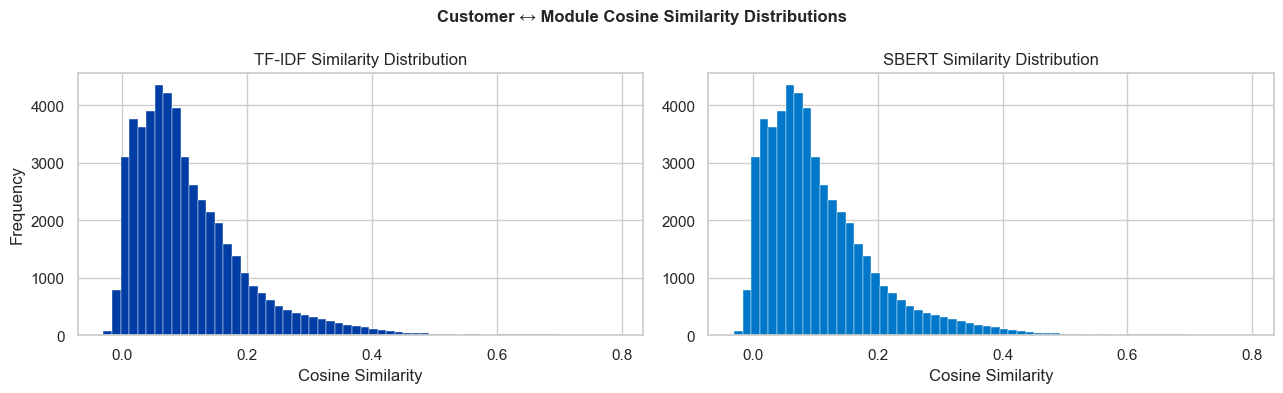

In [11]:
# ── Visualise similarity distributions ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Sample 50k pairs for plotting speed
sample_flat_tfidf = sim_tfidf.flatten()[::20]
sample_flat_sbert = sim_sbert.flatten()[::20]

axes[0].hist(sample_flat_tfidf, bins=60, color="#003DA5", edgecolor="white", linewidth=0.3)
axes[0].set_title("TF-IDF Similarity Distribution")
axes[0].set_xlabel("Cosine Similarity")
axes[0].set_ylabel("Frequency")

axes[1].hist(sample_flat_sbert, bins=60, color="#0077C8", edgecolor="white", linewidth=0.3)
axes[1].set_title("SBERT Similarity Distribution")
axes[1].set_xlabel("Cosine Similarity")

plt.suptitle("Customer ↔ Module Cosine Similarity Distributions",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/similarity_distributions.png", dpi=150)
plt.show()

---
## Stage 4 — Score Fusion + Category-Aware Boosting

This stage replaces clustering. Rather than discovering structure that already exists in `Topic_Domain`, we use those expert-defined categories directly as explicit boosters in the scoring formula.

### Fusion formula

$$\text{score}(c, m) = 0.35 \cdot \text{sim}_{\text{TF-IDF}}(c,m) + 0.65 \cdot \text{sim}_{\text{SBERT}}(c,m) + \text{boosts}(c, m)$$

### Boosts applied

| Boost | Value | Rationale |
|-------|-------|-----------|
| **Domain alignment** | +0.08 | Customer objective maps to module Topic_Domain |
| **Language match** | +0.06 | Customer language == module language |
| **OPCO eligible** | +0.05 | Both customer and module are OPCO-eligible |
| **Skill alignment** | +0.04 | Module is at or one level above customer skill |
| **Contract + Cert** | +0.03 | Contract customer + certified module |
| **Format match** | +0.03 | Customer preferred format matches module format |
| **Duration penalty** | −0.10 | Module duration exceeds customer availability |

In [12]:
# ── Domain alignment map ──────────────────────────────────────────────────────
# Maps keywords in Training_Objective to module Topic_Domain values.
# This is where the expert-defined catalogue structure does the work
# that clustering was trying (and failing) to approximate.

OBJECTIVE_TO_DOMAIN = {
    "Urology & Critical Care":          ["ttm", "temperature", "icu", "critical",
                                          "réanimation", "hypothermie", "foley",
                                          "urolog", "bodyguar"],
    "Medication Management":            ["alaris", "pyxis", "infusion", "pump",
                                          "medication", "dispensing", "rowa",
                                          "guardrails", "drug", "perfusion",
                                          "médicament", "dispensation", "pharmacie",
                                          "healthsight", "opco", "qualiopi"],
    "Vascular Access & Infusion":       ["picc", "vascular", "catheter", "iv",
                                          "nexiva", "midline", "piccline", "access",
                                          "accès", "vasculaire", "insertion"],
    "Specimen Collection & Diagnostics": ["vacutainer", "specimen", "blood",
                                           "preanalytical", "collection", "microtainer",
                                           "a-line", "preset", "prélèvement",
                                           "préanalytique", "sang"],
}

def infer_domain_from_objective(objective: str) -> str:
    """Return the most likely Topic_Domain based on objective keywords."""
    obj_lower = objective.lower()
    for domain, keywords in OBJECTIVE_TO_DOMAIN.items():
        if any(kw in obj_lower for kw in keywords):
            return domain
    return None

# Pre-compute domain inference for all customers
customers_df["Inferred_Domain"] = customers_df["Training_Objective"].apply(
    infer_domain_from_objective
)

domain_coverage = customers_df["Inferred_Domain"].notna().mean()
print(f"Domain inference coverage: {domain_coverage:.1%} of customers")
print(customers_df["Inferred_Domain"].value_counts(dropna=False).to_string())

Domain inference coverage: 100.0% of customers
Inferred_Domain
Medication Management                513
Specimen Collection & Diagnostics    176
Vascular Access & Infusion           162
Urology & Critical Care              149


In [13]:
# ── Score fusion with category-aware boosting ─────────────────────────────────
print("Fusing scores and applying rule-based boosts ...")

# Pre-extract module arrays (vectorised operations — no Python loops over modules)
mod_lang      = modules_df["Language"].values
mod_opco      = (modules_df["OPCO_Eligible"] == "Yes").values.astype(float)
mod_cert      = (modules_df["Certification"] == "Yes").values.astype(float)
mod_fmt       = modules_df["Delivery_Format"].values
mod_skill_num = modules_df["Skill_Level"].map(SKILL_ORDER).fillna(1).values
mod_dur       = modules_df["Duration_Hours"].values
mod_domain    = modules_df["Topic_Domain"].values

# Initialise fused score matrix
all_scores = W_TFIDF * sim_tfidf + W_SBERT * sim_sbert   # baseline fusion

# Apply per-customer boosts (loop over customers only — vectorised over modules)
for i, (_, cust) in enumerate(customers_df.iterrows()):

    # ① Domain alignment — the key replacement for clustering
    inferred = cust["Inferred_Domain"]
    if inferred:
        domain_match = (mod_domain == inferred).astype(float)
        all_scores[i] += BOOST_DOMAIN * domain_match

    # ② Language match
    all_scores[i] += BOOST_LANGUAGE * (mod_lang == cust["Language"]).astype(float)

    # ③ OPCO eligibility
    if str(cust["OPCO_Eligibility"]).lower() == "yes":
        all_scores[i] += BOOST_OPCO * mod_opco

    # ④ Contract + certification
    if str(cust["Has_BD_Contract"]).lower() == "yes":
        all_scores[i] += BOOST_CONTRACT_CERT * mod_cert

    # ⑤ Skill alignment: reward modules at or just one level above customer
    cust_skill_num = SKILL_ORDER.get(str(cust["Skill_Level_Self_Assessed"]), 1)
    skill_diff     = mod_skill_num - cust_skill_num
    aligned        = ((skill_diff >= 0) & (skill_diff <= 1)).astype(float)
    all_scores[i] += BOOST_SKILL * aligned

    # ⑥ Format preference
    all_scores[i] += BOOST_FORMAT * (mod_fmt == cust["Format_Preference"]).astype(float)

    # ⑦ Duration penalty — hard constraint: module too long for availability
    cust_avail = float(cust["Available_Time_Hours"])
    all_scores[i] -= PENALTY_DURATION * (mod_dur > cust_avail).astype(float)

print(f"  Fused score matrix: {all_scores.shape}")
print(f"  Score range : [{all_scores.min():.4f}, {all_scores.max():.4f}]")
print("\n✅ Score fusion complete")

Fusing scores and applying rule-based boosts ...
  Fused score matrix: (1000, 1000)
  Score range : [-0.1224, 1.0191]

✅ Score fusion complete


---
## Stage 5 — MMR Re-ranking

**The problem with pure cosine ranking:** the top-5 results for a customer might be 5 very similar modules on the same product. High relevance, zero diversity — useless.

**Maximal Marginal Relevance (MMR)** solves this by iteratively selecting items that are both *relevant* (high fusion score) and *different from already-selected items* (low similarity to the current selection).

$$\text{MMR} = \arg\max_{d_i \in R \setminus S} \left[ \lambda \cdot \text{score}(d_i) - (1-\lambda) \cdot \max_{d_j \in S} \text{sim}(d_i, d_j) \right]$$

With `λ = 0.70` we lean toward relevance but ensure the 5 picks cover different angles of the customer's learning needs.

In [14]:
def mmr_rerank(
    scores:        np.ndarray,    # fusion scores for all modules (1D)
    module_embeds: np.ndarray,    # SBERT embeddings for all modules
    candidate_idx: np.ndarray,    # pre-filtered candidate indices
    top_k:         int   = TOP_K,
    lam:           float = MMR_LAMBDA,
) -> list:
    """
    Maximal Marginal Relevance re-ranking.

    Parameters
    ----------
    scores        : fusion score for every module (shape: n_modules)
    module_embeds : L2-normalised embedding matrix (shape: n_modules × dim)
    candidate_idx : indices of the pre-filtered candidate pool
    top_k         : number of items to select
    lam           : lambda — 1.0 = pure relevance, 0.0 = pure diversity

    Returns
    -------
    List of selected module indices in ranked order.
    """
    if len(candidate_idx) <= top_k:
        return candidate_idx.tolist()

    selected  = []
    remaining = list(candidate_idx)

    while len(selected) < top_k and remaining:
        if not selected:
            # First pick: highest relevance score
            best = max(remaining, key=lambda i: scores[i])
        else:
            sel_embeds = module_embeds[selected]      # shape: (|S| × dim)
            best, best_val = None, -np.inf
            for idx in remaining:
                rel           = scores[idx]
                sim_to_sel    = np.max(np.dot(sel_embeds, module_embeds[idx]))
                mmr_val       = lam * rel - (1 - lam) * sim_to_sel
                if mmr_val > best_val:
                    best, best_val = idx, mmr_val

        selected.append(best)
        remaining.remove(best)

    return selected

print("✅ MMR function defined")

✅ MMR function defined


In [15]:
# ── Generate recommendations for all customers ────────────────────────────────
print(f"Generating top-{TOP_K} recommendations for {len(customers_df):,} customers ...")

records = []

for i, (_, cust) in enumerate(customers_df.iterrows()):
    scores_i      = all_scores[i]
    candidate_idx = np.argsort(scores_i)[::-1][:CANDIDATE_POOL]

    # MMR re-ranking on the candidate pool
    top_idx = mmr_rerank(scores_i, M_sbert, candidate_idx)

    for rank, mod_idx in enumerate(top_idx, start=1):
        mod = modules_df.iloc[mod_idx]
        records.append({
            "Customer_ID":         cust["Customer_ID"],
            "Customer_Role":       cust.get("Customer_Role", ""),
            "Specialty_Service":   cust.get("Specialty_Service", ""),
            "Country":             cust.get("Country", ""),
            "Training_Objective":  cust.get("Training_Objective", ""),
            "Rank":                rank,
            "Module_ID":           mod["Module_ID"],
            "Module_Title":        mod["Module_Title"],
            "Business_Unit":       mod.get("Business_Unit_Full", ""),
            "Topic_Domain":        mod["Topic_Domain"],
            "Delivery_Format":     mod["Delivery_Format"],
            "Skill_Level":         mod["Skill_Level"],
            "Duration_Hours":      mod["Duration_Hours"],
            "Certification":       mod.get("Certification", ""),
            "OPCO_Eligible":       mod.get("OPCO_Eligible", ""),
            "Fusion_Score":        round(float(scores_i[mod_idx]), 4),
            "Description_Snippet": str(mod["Description"])[:120] + "…",
        })

recs_df = pd.DataFrame(records)
print(f"\n✅ Recommendations generated: {len(recs_df):,} rows ({len(customers_df)} customers × {TOP_K} recs)")

# Preview
print("\nSample recommendations (first 3 customers):")
display(
    recs_df[recs_df["Customer_ID"].isin(customers_df["Customer_ID"].head(3))]
    [["Customer_ID", "Customer_Role", "Rank", "Module_ID", "Module_Title",
      "Topic_Domain", "Skill_Level", "Fusion_Score"]]
    .set_index(["Customer_ID", "Rank"])
)

Generating top-5 recommendations for 1,000 customers ...

✅ Recommendations generated: 5,000 rows (1000 customers × 5 recs)

Sample recommendations (first 3 customers):


Customer_Role Module_ID  \
Customer_ID Rank                                  
HCP0001     1     Biomedical Engineer    BD6658   
            2     Biomedical Engineer    BD4272   
            3     Biomedical Engineer    BD0935   
            4     Biomedical Engineer    BD2946   
            5     Biomedical Engineer    BD4922   
HCP0002     1                   Nurse    BD5245   
            2                   Nurse    BD1286   
            3                   Nurse    BD6888   
            4                   Nurse    BD1738   
            5                   Nurse    BD6632   
HCP0003     1               Physician    BD9423   
            2               Physician    BD3343   
            3               Physician    BD1286   
            4               Physician    BD1888   
            5               Physician    BD9341   

                                                                                     Module_Title  \
Customer_ID Rank                                                                                    
HCP0001     1                             Rotarex™ Rotational Excisional Atherectomy System eBook   
            2                                                         ES_Prevención de Oclusiones   
            3                                                          DE_BD PosiFlush Handhabung   
            4                                                   Knowledge check BD PowerGlide Pro   
            5                                                 DE_BD Nexiva Single Port Handhabung   
HCP0002     1                           Nurse/Clinician - Pyxis ES Link v1.3 for Nurses - CLP1190   
            2                             BD Preset Eclipse™ Spruta för arteriell blodprovtagning   
            3                                           EMEA_PT_MDS_Rodovia_ Manutenção_BD-128485   
            4                                                              Nivel intermedio TTM U   
            5       v9.33 BD Alaris™ System Essentials: Training Resources for Clinical Educators   
HCP0003     1                                              BD A-Line artériás vérvételi fecskendő   
            2     Best Practices zur Verringerung präanalytischer Fehler im Rahmen der Blutent...   
            3                             BD Preset Eclipse™ Spruta för arteriell blodprovtagning   
            4                 Best Practices zur Blutprobenentnahme über vaskuläre Zugangssysteme   
            5     Best Practices in Blood Specimen Collection from Vascular Access Devices (VADs)   

                                       Topic_Domain   Skill_Level  \
Customer_ID Rank                                                    
HCP0001     1            Vascular Access & Infusion      Advanced   
            2            Vascular Access & Infusion      Advanced   
            3            Vascular Access & Infusion      Advanced   
            4            Vascular Access & Infusion      Advanced   
            5            Vascular Access & Infusion  Intermediate   
HCP0002     1                 Medication Management  Intermediate   
            2     Specimen Collection & Diagnostics  Intermediate   
            3            Vascular Access & Infusion  Intermediate   
            4               Urology & Critical Care      Beginner   
            5                 Medication Management      Beginner   
HCP0003     1     Specimen Collection & Diagnostics  Intermediate   
            2     Specimen Collection & Diagnostics      Advanced   
            3     Specimen Collection & Diagnostics  Intermediate   
            4     Specimen Collection & Diagnostics  Intermediate   
            5     Specimen Collection & Diagnostics      Advanced   

                  Fusion_Score  
Customer_ID Rank                
HCP0001     1           0.7931  
            2           0.5659  
            3           0.5097  
            4           0.5084  
            5           0.5148  
HCP0002     1           0.4406  


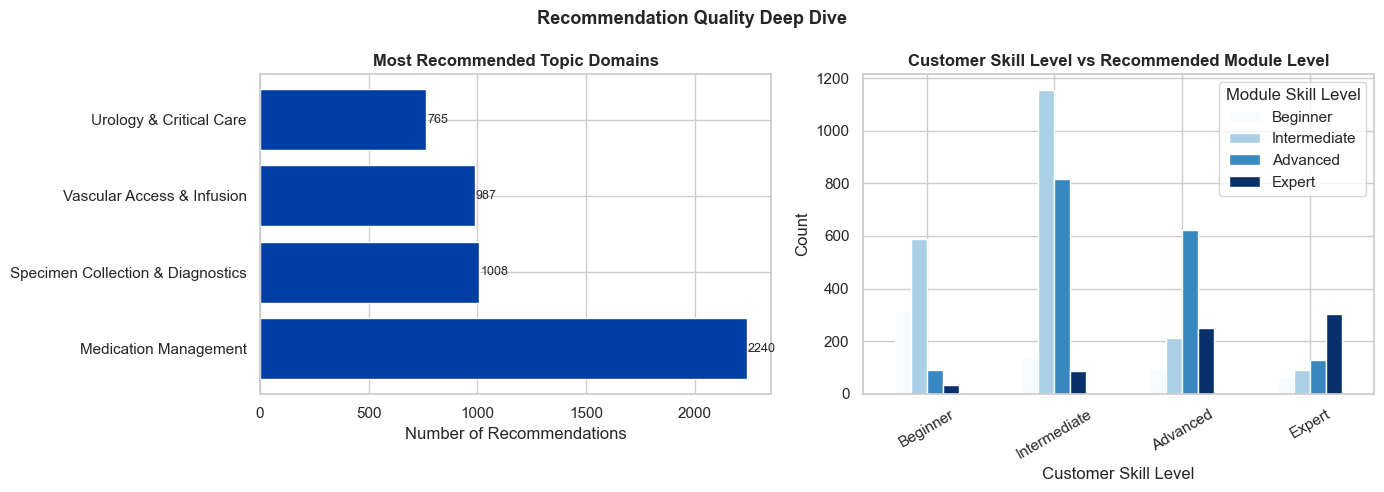

In [19]:
# ── Deep-dive visualisations ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Most recommended Topic Domains
domain_counts = recs_df["Topic_Domain"].value_counts()
axes[0].barh(domain_counts.index, domain_counts.values,
             color="#003DA5")
axes[0].set_title("Most Recommended Topic Domains", fontweight="bold")
axes[0].set_xlabel("Number of Recommendations")
for bar, val in zip(axes[0].patches, domain_counts.values):
    axes[0].text(val + 5, bar.get_y() + bar.get_height() / 2,
                 str(val), va="center", fontsize=9)

# 2. Skill alignment: customer skill vs recommended module skill
skill_order = ["Beginner", "Intermediate", "Advanced", "Expert"]
merged = recs_df.merge(
    customers_df[["Customer_ID", "Skill_Level_Self_Assessed"]],
    on="Customer_ID", how="left"
)
skill_cross = (
    merged.groupby(["Skill_Level_Self_Assessed", "Skill_Level"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=[s for s in skill_order if s in merged["Skill_Level_Self_Assessed"].unique()],
             columns=[s for s in skill_order if s in merged["Skill_Level"].unique()],
             fill_value=0)
)
skill_cross.plot(kind="bar", ax=axes[1],
                 colormap="Blues", edgecolor="white")
axes[1].set_title("Customer Skill Level vs Recommended Module Level",
                  fontweight="bold")
axes[1].set_xlabel("Customer Skill Level")
axes[1].set_ylabel("Count")
axes[1].legend(title="Module Skill Level", bbox_to_anchor=(1, 1))
axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("Recommendation Quality Deep Dive", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/quality_deepdive.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Stage 7 — Output

Export the final recommendations and evaluation metrics.

In [21]:
# ── Save recommendations ──────────────────────────────────────────────────────
recs_path = f"{OUTPUT_DIR}/BD_Recommendations.csv"
recs_df.to_csv(recs_path, index=False, encoding="utf-8")
print(f"✅ Recommendations saved → {recs_path}")
print(f"   {len(recs_df):,} rows  ({len(customers_df)} customers × {TOP_K} recommendations each)")

# ── Save evaluation metrics ───────────────────────────────────────────────────
metrics_path = f"{OUTPUT_DIR}/evaluation_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(eval_results, f, indent=2)
print(f"✅ Metrics saved       → {metrics_path}")

# ── Final summary ─────────────────────────────────────────────────────────────
print("\n" + "═" * 50)
print("  PIPELINE COMPLETE — SUMMARY")
print("═" * 50)
print(f"  Modules in catalogue  : {len(modules_df):,}")
print(f"  Customers profiled    : {len(customers_df):,}")
print(f"  Recommendations made  : {len(recs_df):,}")
print(f"  SBERT mode            : {USE_SBERT}")
print(f"  MMR lambda            : {MMR_LAMBDA}")
print("─" * 50)
for k, v in eval_results.items():
    print(f"  {k:<22}: {v}")
print("═" * 50)

✅ Recommendations saved → outputs/BD_Recommendations.csv
   5,000 rows  (1000 customers × 5 recommendations each)
✅ Metrics saved       → outputs/evaluation_metrics.json

══════════════════════════════════════════════════
  PIPELINE COMPLETE — SUMMARY
══════════════════════════════════════════════════
  Modules in catalogue  : 1,000
  Customers profiled    : 1,000
  Recommendations made  : 5,000
  SBERT mode            : False
  MMR lambda            : 0.7
──────────────────────────────────────────────────
  Precision@5           : 0.8478
  NDCG@5                : 0.7561
  ILD (Diversity)       : 0.3486
  Coverage %            : 47.0
══════════════════════════════════════════════════


---
## Appendix — Pipeline Design Decisions

### Why drop `Target_Roles`?
BD's Academy website does not expose this field. Keeping it would mean training on a signal that has no equivalent at inference time on real data, making the model inconsistent when applied to the actual Thomas dataset.

### Why no clustering?
Clustering is an unsupervised technique for *discovering* hidden groupings when no labels exist. `Topic_Domain` and `Business_Unit_Full` are expert-defined categories already in the data. Clustering at best rediscovers these in a noisier form — it adds complexity without adding information. We use those columns directly as explicit boosters in Stage 4, which is more interpretable, controllable, and honest.

### Why two embeddings and not just SBERT?
SBERT is powerful but can miss exact product-name matches — *"BD Alaris™"* is a proper noun that a general semantic model may not handle better than exact string matching. TF-IDF is perfect for this. The blend captures both exact lexical signal (TF-IDF) and deep semantic intent (SBERT).

### Why build a customer sentence instead of a feature vector?
Module descriptions are text. If customers are encoded as numeric vectors, the two representations live in incompatible spaces and cosine similarity has no valid interpretation. The profile sentence puts both sides into the same embedding space.

### Multilingual note
For production use with BD's full EU dataset (21 languages), use `paraphrase-multilingual-mpnet-base-v2` for the highest quality multilingual SBERT embeddings. The TF-IDF model already handles multilingual text via unicode tokenisation and the `strip_accents` parameter.